# Verfahrenswahrscheinlichkeit bei festem $p_0$

Die linke Grafik zeigt Realisationen von $H=X/n$ auf der Vertikalen $p=p_0$. Die rechte Grafik zeigt die zugehörigen Wilson-Konfidenzintervalle. Beide Darstellungen beruhen auf denselben Stichproben und verbinden damit die Sicht im $(p,h)$-Raum mit der üblichen Intervallgrafik.

Eine Ergebniszahl wird bewusst nicht ausgegeben. Die gemeinsame Grafik bleibt ein **Denkraum**: Welche markierten Punkte links gehören zu welchen Intervallen rechts -- und was lässt sich daraus über das Verfahren vermuten?

## Eingaben

Nur die folgende Zelle muss verändert werden. Die Klasse `Config` bündelt vier Arten von Eingaben:

- mathematische und simulationsbezogene Eingaben,
- Elemente der Grafik,
- Beschriftung,
- Anzeige und Speicherung.

Der Zufallszahlengenerator wird mit `seed` initialisiert. Dadurch entstehen bei unveränderten Eingaben immer dieselben Stichproben.

In [1]:
from __future__ import annotations

from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from statistics import NormalDist

import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.ticker import MaxNLocator
import numpy as np


@dataclass(frozen=True)
class Config:
    # Mathematische und simulationsbezogene Eingaben
    n: int = 100
    p0: float = 0.27
    gamma: float = 0.90
    number_of_samples: int = 50
    seed: int = 7

    # Elemente der Grafik
    stack_spacing: float = 0.015
    show_acceptance_limits: bool = True

    # Beschriftung der Grafik
    show_title: bool = True
    show_subtitle: bool = True

    # Ausgabe des Notebooks
    show_figure: bool = True
    save_figure: bool = True
    save_formats: tuple[str, ...] = ("png", "pdf")
    output_dir: str = "fig"
    png_dpi: int = 240


cfg = Config()

## Prüfung, Simulation und mathematische Berechnung

Zunächst werden die Eingaben geprüft. Danach folgen voneinander getrennte Funktionen für Simulation, Prognoseband, Wilson-Intervalle und Stapelung gleicher Realisationen. Alle benötigten Größen werden als Argumente übergeben; die mathematischen Funktionen greifen nicht auf globale Zwischenwerte zu.

Für das normalapproximative Prognoseband gilt

$$
h=p\pm z\sqrt{\frac{p(1-p)}{n}}.
$$

Die Wilson-Intervalle entstehen durch die Inversion desselben Score-Tests. Im Programm wird deshalb zusätzlich geprüft, ob die beiden Darstellungen für jede simulierte Stichprobe dieselbe Entscheidung liefern.

In [2]:
@dataclass(frozen=True)
class Calculation:
    z: float
    hits: np.ndarray
    relative_frequencies: np.ndarray
    wilson_lower: np.ndarray
    wilson_upper: np.ndarray
    contains_p0: np.ndarray
    acceptance_lower: float
    acceptance_upper: float
    dotplot_p: np.ndarray
    dotplot_h: np.ndarray
    dotplot_inside: np.ndarray
    p_grid: np.ndarray
    prediction_lower: np.ndarray
    prediction_upper: np.ndarray


def validate_config(cfg: Config) -> None:
    if not isinstance(cfg.n, int) or isinstance(cfg.n, bool) or cfg.n <= 0:
        raise ValueError("n muss eine positive ganze Zahl sein.")
    if not 0.0 <= cfg.p0 <= 1.0:
        raise ValueError("p0 muss zwischen 0 und 1 liegen.")
    if not 0.0 < cfg.gamma < 1.0:
        raise ValueError("gamma muss zwischen 0 und 1 liegen.")
    if (
        not isinstance(cfg.number_of_samples, int)
        or isinstance(cfg.number_of_samples, bool)
        or cfg.number_of_samples <= 0
    ):
        raise ValueError("number_of_samples muss eine positive ganze Zahl sein.")
    if not isinstance(cfg.seed, int) or isinstance(cfg.seed, bool) or cfg.seed < 0:
        raise ValueError("seed muss eine nichtnegative ganze Zahl sein.")
    if cfg.stack_spacing <= 0.0:
        raise ValueError("stack_spacing muss positiv sein.")
    if cfg.png_dpi <= 0:
        raise ValueError("png_dpi muss positiv sein.")
    if not cfg.output_dir.strip():
        raise ValueError("output_dir darf nicht leer sein.")
    if Path(cfg.output_dir).is_absolute():
        raise ValueError("output_dir muss ein relativer Pfad sein.")

    formats = {fmt.lower().lstrip(".") for fmt in cfg.save_formats}
    if cfg.save_figure and not formats:
        raise ValueError("save_formats darf beim Speichern nicht leer sein.")
    unsupported = formats - {"png", "pdf"}
    if unsupported:
        names = ", ".join(sorted(unsupported))
        raise ValueError(f"Nicht unterstützte Speicherformate: {names}")


def prediction_bounds(
    p: np.ndarray,
    *,
    n: int,
    z: float,
) -> tuple[np.ndarray, np.ndarray]:
    half_width = z * np.sqrt(p * (1.0 - p) / n)
    return p - half_width, p + half_width


def wilson_intervals(
    hits: np.ndarray,
    *,
    n: int,
    z: float,
) -> tuple[np.ndarray, np.ndarray]:
    h = hits / n
    denominator = 1.0 + z**2 / n
    center = (h + z**2 / (2.0 * n)) / denominator
    half_width = (
        z
        * np.sqrt(h * (1.0 - h) / n + z**2 / (4.0 * n**2))
        / denominator
    )
    return center - half_width, center + half_width


def dotplot_positions(
    hits: np.ndarray,
    *,
    n: int,
    p0: float,
    stack_spacing: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Gleiche h-Werte werden von p0 aus nur nach rechts gestapelt."""
    p_points: list[float] = []
    h_points: list[float] = []

    for k, multiplicity in sorted(Counter(hits).items()):
        h_value = k / n
        p_points.extend(p0 + stack_spacing * np.arange(multiplicity))
        h_points.extend([h_value] * multiplicity)

    return np.asarray(p_points), np.asarray(h_points)


def calculate(cfg: Config) -> Calculation:
    validate_config(cfg)

    z = NormalDist().inv_cdf((1.0 + cfg.gamma) / 2.0)
    rng = np.random.default_rng(cfg.seed)
    hits = rng.binomial(cfg.n, cfg.p0, size=cfg.number_of_samples)
    relative_frequencies = hits / cfg.n

    wilson_lower, wilson_upper = wilson_intervals(
        hits, n=cfg.n, z=z
    )
    contains_p0 = (wilson_lower <= cfg.p0) & (cfg.p0 <= wilson_upper)

    acceptance_half_width = z * np.sqrt(cfg.p0 * (1.0 - cfg.p0) / cfg.n)
    acceptance_lower = cfg.p0 - acceptance_half_width
    acceptance_upper = cfg.p0 + acceptance_half_width
    inside_acceptance_region = (
        (acceptance_lower <= relative_frequencies)
        & (relative_frequencies <= acceptance_upper)
    )

    # Beide Tafeln beruhen auf demselben invertierten Score-Test.
    if not np.array_equal(contains_p0, inside_acceptance_region):
        raise AssertionError("Die beiden Darstellungen stimmen nicht überein.")

    dotplot_p, dotplot_h = dotplot_positions(
        hits,
        n=cfg.n,
        p0=cfg.p0,
        stack_spacing=cfg.stack_spacing,
    )
    dotplot_inside = (
        (acceptance_lower <= dotplot_h) & (dotplot_h <= acceptance_upper)
    )

    p_grid = np.linspace(0.0, 1.0, 2001)
    prediction_lower, prediction_upper = prediction_bounds(
        p_grid, n=cfg.n, z=z
    )

    return Calculation(
        z=z,
        hits=hits,
        relative_frequencies=relative_frequencies,
        wilson_lower=wilson_lower,
        wilson_upper=wilson_upper,
        contains_p0=contains_p0,
        acceptance_lower=acceptance_lower,
        acceptance_upper=acceptance_upper,
        dotplot_p=dotplot_p,
        dotplot_h=dotplot_h,
        dotplot_inside=dotplot_inside,
        p_grid=p_grid,
        prediction_lower=prediction_lower,
        prediction_upper=prediction_upper,
    )

## Grafik

Die Funktion `create_figure()` erzeugt ausschließlich die Grafik. Titel und Untertitel können unabhängig voneinander ein- und ausgeblendet werden. Der Untertitel enthält nur Eingaben; eine Ergebniszeile gibt es in dieser Datei bewusst nicht.

Gleiche relative Häufigkeiten werden links von $p_0$ aus ausschließlich nach rechts gestapelt. Rechts wird für jede Stichprobe das zugehörige Wilson-Konfidenzintervall dargestellt.

In [3]:
def interval_axis_limits(
    calculation: Calculation,
    *,
    p0: float,
) -> tuple[float, float]:
    data_lower = min(float(np.min(calculation.wilson_lower)), p0)
    data_upper = max(float(np.max(calculation.wilson_upper)), p0)
    padding = max(0.02, 0.08 * (data_upper - data_lower))
    lower = max(0.0, np.floor((data_lower - padding) * 10.0) / 10.0)
    upper = min(1.0, np.ceil((data_upper + padding) * 10.0) / 10.0)

    if upper - lower < 0.2:
        center = (lower + upper) / 2.0
        lower = max(0.0, center - 0.1)
        upper = min(1.0, center + 0.1)

    return float(lower), float(upper)


def create_figure(
    cfg: Config,
    calculation: Calculation,
) -> tuple[Figure, tuple[Axes, Axes]]:
    fig, (ax_left, ax_right) = plt.subplots(
        1,
        2,
        figsize=(11.2, 5.8),
        gridspec_kw={"width_ratios": [1.0, 1.05]},
    )

    # Links: Neyman-Raum mit den Realisationen H = X/n.
    ax_left.plot(
        calculation.p_grid,
        calculation.prediction_lower,
        color="0.45",
        linestyle=":",
        linewidth=2.2,
    )
    ax_left.plot(
        calculation.p_grid,
        calculation.prediction_upper,
        color="0.45",
        linestyle=":",
        linewidth=2.2,
    )
    ax_left.axvline(cfg.p0, color="0.72", linestyle="--", linewidth=2.0)
    ax_left.scatter(
        calculation.dotplot_p[calculation.dotplot_inside],
        calculation.dotplot_h[calculation.dotplot_inside],
        s=10,
        facecolors="white",
        edgecolors="black",
        linewidths=1.2,
        zorder=3,
    )
    ax_left.scatter(
        calculation.dotplot_p[~calculation.dotplot_inside],
        calculation.dotplot_h[~calculation.dotplot_inside],
        s=20,
        facecolors="red",
        edgecolors="black",
        linewidths=1.3,
        zorder=4,
    )
    ax_left.set(
        xlim=(0.0, 1.0),
        ylim=(0.0, 1.0),
        xlabel=r"$p$",
        ylabel=r"$h$",
        title=r"Realisationen von $H=X/n$",
    )
    ax_left.set_aspect("equal", adjustable="box")

    # Rechts: Wilson-Intervalle für genau dieselben Stichproben.
    sample_number = np.arange(1, cfg.number_of_samples + 1)
    ax_right.hlines(
        sample_number,
        calculation.wilson_lower,
        calculation.wilson_upper,
        color="0.38",
        linewidth=2.0,
        zorder=1,
    )
    if cfg.show_acceptance_limits:
        ax_right.axvline(
            calculation.acceptance_lower,
            color="0.72",
            linestyle="--",
            linewidth=2.0,
            zorder=0,
        )
        ax_right.axvline(
            calculation.acceptance_upper,
            color="0.72",
            linestyle="--",
            linewidth=2.0,
            zorder=0,
        )
    ax_right.axvline(
        cfg.p0, color="0.35", linestyle="--", linewidth=2.0, zorder=0
    )
    ax_right.scatter(
        calculation.relative_frequencies[calculation.contains_p0],
        sample_number[calculation.contains_p0],
        s=15,
        facecolors="white",
        edgecolors="black",
        linewidths=1.2,
        zorder=3,
    )
    ax_right.scatter(
        calculation.relative_frequencies[~calculation.contains_p0],
        sample_number[~calculation.contains_p0],
        s=40,
        facecolors="red",
        edgecolors="black",
        linewidths=1.3,
        zorder=4,
    )

    right_xlim = interval_axis_limits(calculation, p0=cfg.p0)
    ax_right.set(
        xlim=right_xlim,
        ylim=(0.0, cfg.number_of_samples + 1),
        xlabel=r"$p$",
        ylabel="Stichprobe",
        title="Zugehörige Wilson-Konfidenzintervalle",
    )
    ax_right.set_xticks(
        np.arange(right_xlim[0], right_xlim[1] + 0.05, 0.1)
    )
    ax_right.yaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))
    ax_right.set_box_aspect(1.0)

    for ax in (ax_left, ax_right):
        for spine in ax.spines.values():
            spine.set_color("0.72")
        ax.tick_params(labelsize=10)
        ax.xaxis.label.set_size(13)
        ax.yaxis.label.set_size(13)
        ax.title.set_size(13)

    title = r"Verfahrenswahrscheinlichkeit bei festem $p_0$"
    subtitle = (
        rf"$n={cfg.n},\quad p_0={cfg.p0:.2f},\quad "
        rf"\gamma={cfg.gamma:.2f}$; "
        f"{cfg.number_of_samples} Stichproben; Seed = {cfg.seed}"
    )

    if cfg.show_title and cfg.show_subtitle:
        fig.suptitle(title, fontsize=17, y=0.975)
        fig.text(
            0.5,
            0.925,
            subtitle,
            ha="center",
            va="top",
            fontsize=11,
            color="0.35",
        )
        top = 0.9
    elif cfg.show_title:
        fig.suptitle(title, fontsize=17, y=0.965)
        top = 0.88
    elif cfg.show_subtitle:
        fig.text(
            0.5,
            0.955,
            subtitle,
            ha="center",
            va="top",
            fontsize=11,
            color="0.35",
        )
        top = 0.88
    else:
        top = 0.96

    fig.tight_layout(rect=(0.0, 0.0, 1.0, top))
    return fig, (ax_left, ax_right)

## Ausgabe

Berechnung, Erzeugung der Grafik sowie Anzeige und Speicherung bleiben getrennt. Die Grafik kann unabhängig voneinander angezeigt und gespeichert werden.

Ist `save_figure = True`, wird der relative Unterordner `fig/` bei Bedarf automatisch angelegt. PNG- und PDF-Dateien werden dort gesammelt; das Verzeichnis des Notebooks bleibt frei von einzelnen Grafikdateien.

Der Dateiname wird automatisch aus den Eingaben gebildet. Für die Standardeinstellungen entstehen

- `Verfahrenswahrscheinlichkeit-n100-p027-gamma090-stichproben50-seed07.png`,
- `Verfahrenswahrscheinlichkeit-n100-p027-gamma090-stichproben50-seed07.pdf`.

Die letzte Zelle zeigt ausschließlich die Grafik. Sie gibt weder die Zahl der markierten Fälle noch eine daraus abgeleitete Verfahrenswahrscheinlichkeit aus.

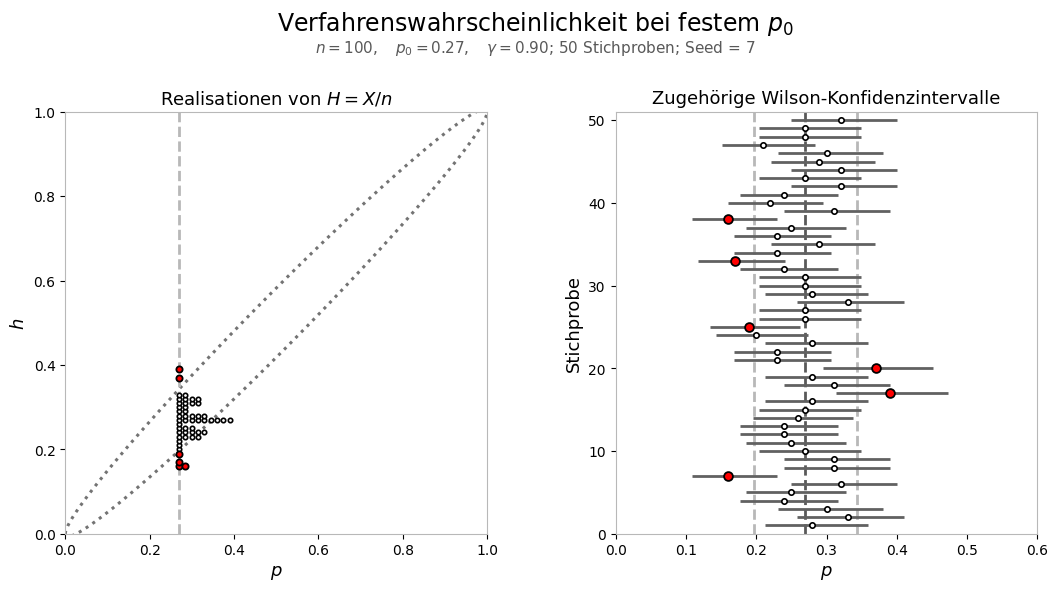

In [4]:
def probability_token(value: float) -> str:
    text = f"{value:.6f}".rstrip("0").rstrip(".")
    integer, separator, decimals = text.partition(".")
    decimals = decimals.ljust(2, "0") if separator else "00"
    return f"{integer}{decimals}".replace("-", "m")


def figure_stem(cfg: Config) -> str:
    p0 = probability_token(cfg.p0)
    gamma = probability_token(cfg.gamma)
    return (
        f"Verfahrenswahrscheinlichkeit-n{cfg.n}-p{p0}-"
        f"gamma{gamma}-stichproben{cfg.number_of_samples}-seed{cfg.seed}"
    )


def save_figure(
    fig: Figure,
    cfg: Config,
) -> tuple[Path, ...]:
    output_dir = Path(cfg.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    stem = figure_stem(cfg)
    saved_files: list[Path] = []

    for raw_format in cfg.save_formats:
        file_format = raw_format.lower().lstrip(".")
        output_path = output_dir / f"{stem}.{file_format}"
        save_options: dict[str, object] = {"bbox_inches": "tight"}
        if file_format == "png":
            save_options["dpi"] = cfg.png_dpi
        fig.savefig(output_path, **save_options)
        saved_files.append(output_path)

    return tuple(saved_files)


def run(cfg: Config) -> tuple[Calculation, tuple[Path, ...]]:
    calculation = calculate(cfg)
    fig, _ = create_figure(cfg, calculation)

    saved_files: tuple[Path, ...] = ()
    if cfg.save_figure:
        saved_files = save_figure(fig, cfg)

    if cfg.show_figure:
        plt.show()
    else:
        plt.close(fig)

    return calculation, saved_files


calculation, saved_files = run(cfg)